In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [15]:
df_index = pd.read_csv("economic_index.csv")
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [16]:
#Drop unneccesary Columns
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace = True)

In [17]:
df_index.columns

Index(['interest_rate', 'unemployment_rate', 'index_price'], dtype='object')

In [19]:
#Check Null Values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

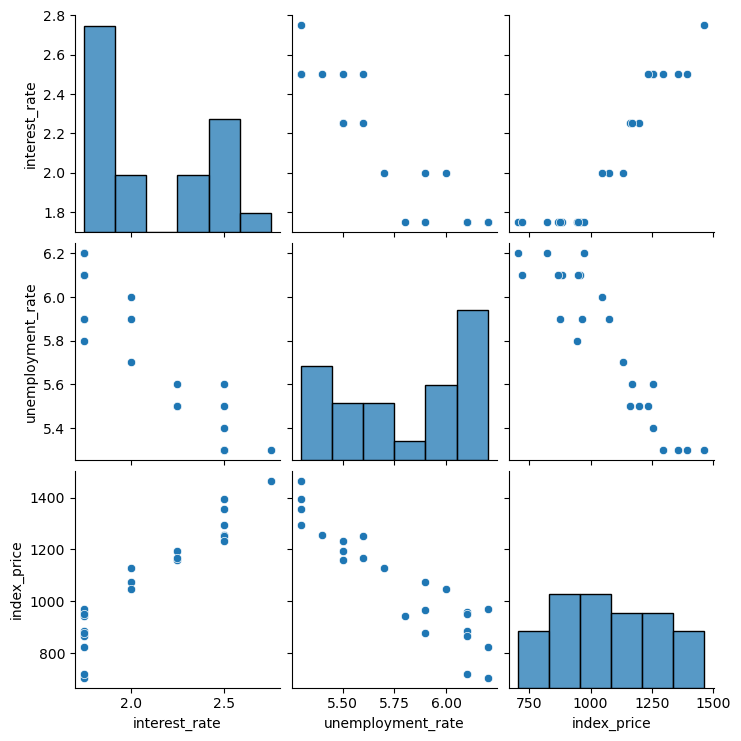

In [21]:
#Visualization
import seaborn as sns
sns.pairplot(df_index)

In [22]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment RAte')

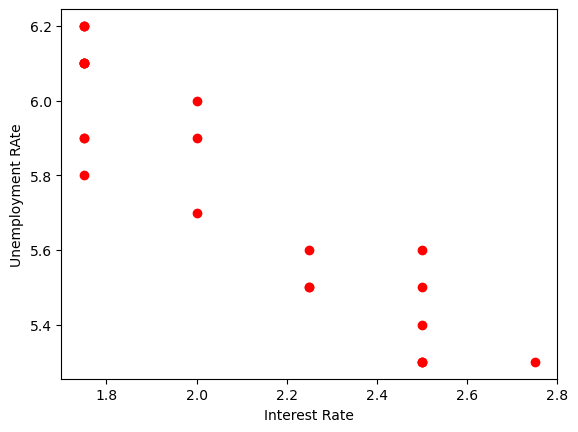

In [24]:
#Visualize more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment RAte")

In [27]:
#X = df_index[['interest_rate','unemployment_rate']]
X = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]

In [28]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [29]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)


<Axes: xlabel='interest_rate', ylabel='index_price'>

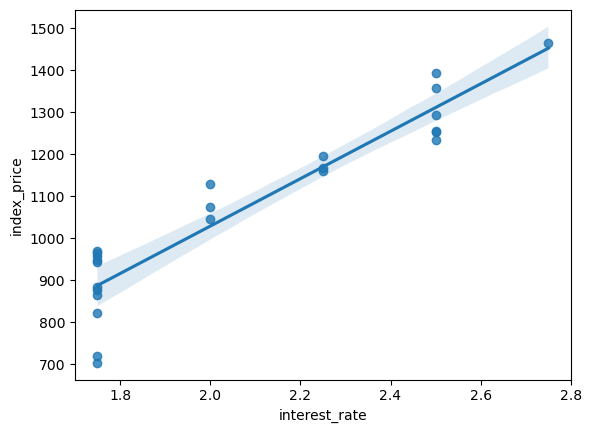

In [33]:
import seaborn as sns
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

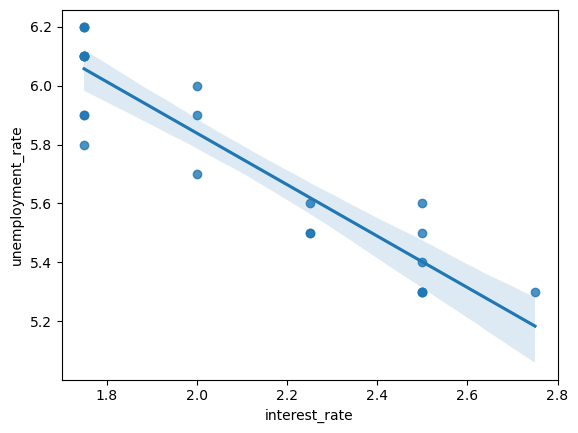

In [35]:
sns.regplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [40]:
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
#Cross Validation
from sklearn.model_selection import cross_val_score
val_score = cross_val_score(reg,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [46]:
np.mean(val_score)

np.float64(-5914.828180162396)

In [47]:
y_pred = reg.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [49]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_absolute_error(y_test,y_pred)
mae = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

59.93578152323556
5793.76288771258
7.741820297787567


In [51]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(r2)

0.8278978091457142


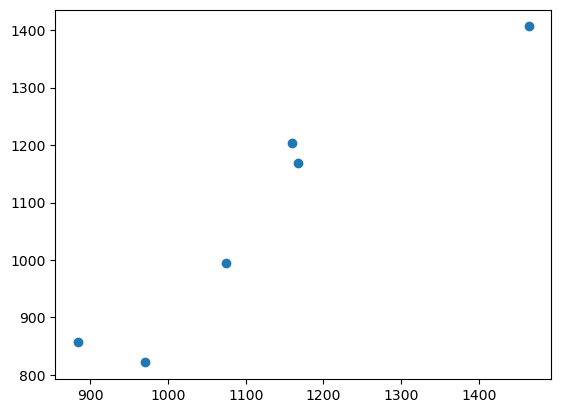

In [52]:
plt.scatter(y_test,y_pred)